Import all libraries

In [28]:
# Data & Plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import spacy
from wordcloud import WordCloud
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import gensim
from gensim import corpora
import re

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Other
from xgboost import XGBClassifier
from scipy.sparse import issparse  # Only if you're checking input format

# Downloads (place at end of import cell)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')  # For lemmatizer


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [3]:
from google.colab import files
uploaded = files.upload()


df = pd.read_csv('customer_support_tickets.csv')
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")
df.head()



Saving customer_support_tickets.csv to customer_support_tickets.csv
Loaded 8469 rows, 17 columns


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


EDA

3.1 Categorical Distributions


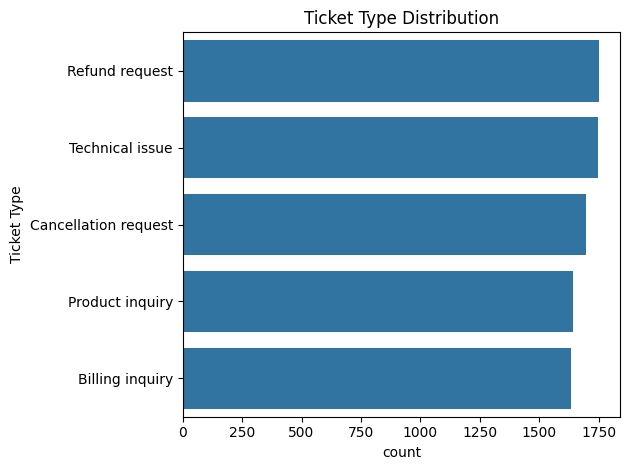

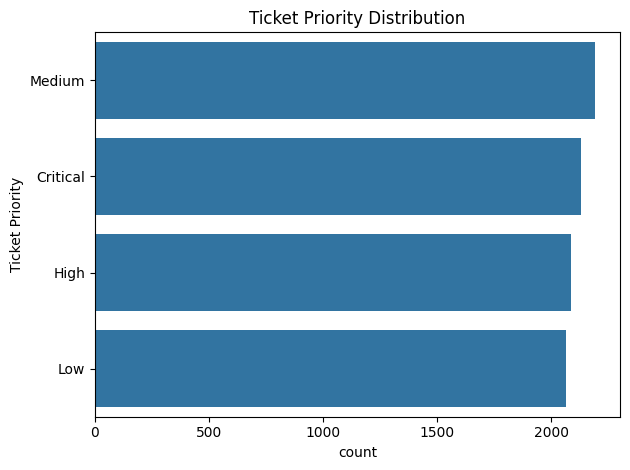

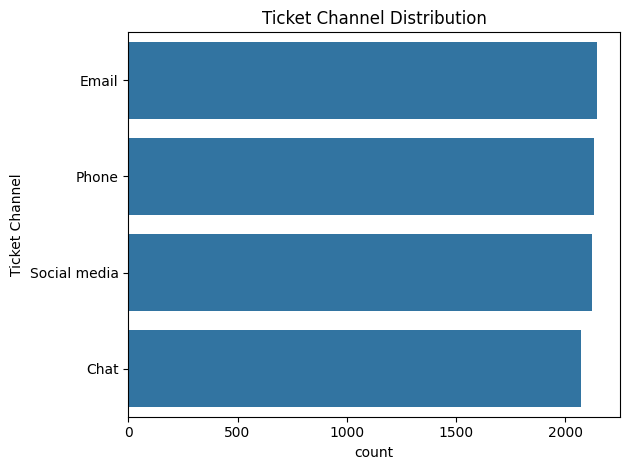

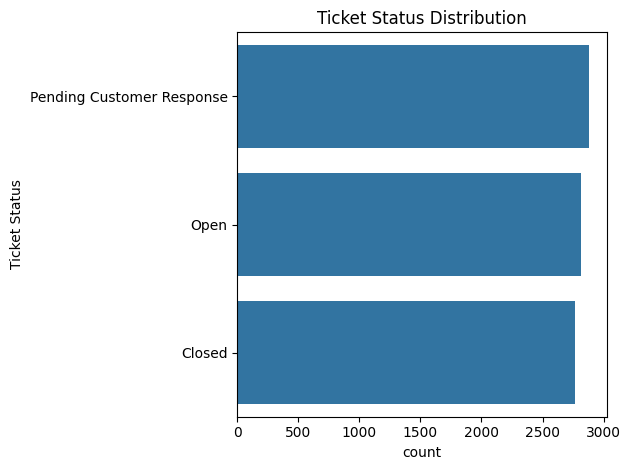

In [5]:
cats = ['Ticket Type','Ticket Priority','Ticket Channel','Ticket Status']
for col in cats:
    plt.figure()
    sns.countplot(y=col, data=df,
                  order=df[col].value_counts().index)
    plt.title(f"{col} Distribution")
    plt.tight_layout()
    plt.show()


3.2 Text Length Histogram

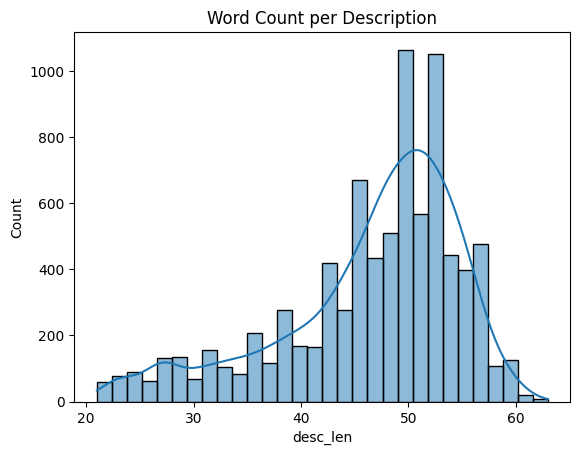

In [6]:
df['desc_len'] = df['Ticket Description'].str.split().apply(len)
plt.figure()
sns.histplot(df['desc_len'], bins=30, kde=True)
plt.title("Word Count per Description")
plt.show()


3.3 Word Cloud of Description

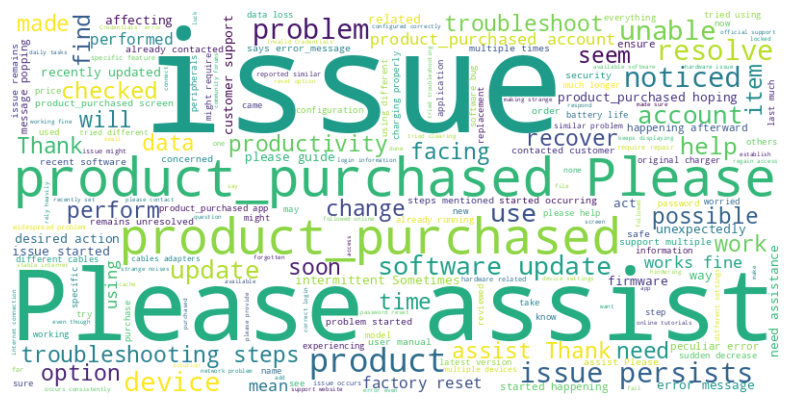

In [7]:
all_text = " ".join(df['Ticket Description'].dropna())
wc = WordCloud(width=800, height=400,
               background_color='white').generate(all_text)
plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()


3.4 Sentiment Distribution

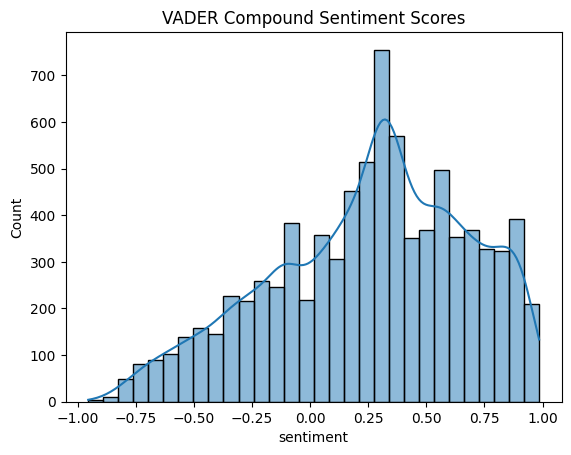

In [8]:
analyzer = SentimentIntensityAnalyzer()
df['sentiment'] = df['Ticket Description'].apply(
    lambda t: analyzer.polarity_scores(str(t))['compound']
)
plt.figure()
sns.histplot(df['sentiment'], bins=30, kde=True)
plt.title("VADER Compound Sentiment Scores")
plt.show()


4. Data Cleaning

In [9]:
# Drop rows missing key fields
df.dropna(subset=['Ticket Description','Ticket Subject'], inplace=True)

# Trim description lengths to 1st–99th percentiles
low, high = df['desc_len'].quantile([0.01,0.99])
df = df[df['desc_len'].between(low, high)].copy()  # Removes outliers

# Basic text normalization
def clean_text(txt):
    txt = txt.lower()
    txt = re.sub(r'http\S+','', txt)
    txt = re.sub(r'[^a-z0-9\s]','', txt)
    return txt

df['clean_desc'] = df['Ticket Description'].apply(clean_text)  # Preps for NLP


5. Feature Engineering


5.1 Categorical & Numeric



In [11]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = ohe.fit_transform(df[cats])
scaler = StandardScaler()
X_num = scaler.fit_transform(df[['desc_len','sentiment']])


5.2 Text Vectorization (TF-IDF)

In [12]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def tokenize_lemmatize(text):
    tokens = text.split()
    return [lemmatizer.lemmatize(tok)
            for tok in tokens if tok not in stop_words]

tfidf = TfidfVectorizer(tokenizer=tokenize_lemmatize,
                        max_features=5000)  # Limits feature size
X_text = tfidf.fit_transform(df['clean_desc'])


/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


5.3 Combine Features & Labels

In [13]:
from scipy import sparse
X = sparse.hstack([X_cat, X_num, X_text])
y = LabelEncoder().fit_transform(df['Ticket Subject'])


6. NLP Demonstrations

6.1 Named Entity Recognition (spaCy)

In [17]:
# Load spaCy model
nlp = spacy.load("en_core_web_sm")  # Pretrained NER model

# Define a function to clean incorrect entities
def clean_entities(doc):
    filtered_ents = []
    for ent in doc.ents:
        # Example filter: remove numeric "DATE" entities like '71701'
        if ent.label_ == 'DATE' and ent.text.isdigit() and len(ent.text) == 5:
            continue  # Skip incorrect date like ZIP code
        filtered_ents.append((ent.text, ent.label_))
    return filtered_ents

# Apply NER to the first 5 descriptions and print corrected entities
for doc in nlp.pipe(df['clean_desc'].iloc[:5]):
    print(clean_entities(doc))

[]
[]
[('yesterday', 'DATE'), ('183', 'CARDINAL')]
[]
[]


6.2 Topic Modeling (Gensim LDA)

In [18]:
processed = [tokenize_lemmatize(txt) for txt in df['clean_desc']]
dictionary = corpora.Dictionary(processed)
dictionary.filter_extremes(no_below=15, no_above=0.1)
bow_corpus = [dictionary.doc2bow(doc) for doc in processed]

lda = gensim.models.LdaModel(
    bow_corpus, num_topics=5,
    id2word=dictionary, passes=10,
    random_state=42
)  # Latent topics

for idx, topic in lda.print_topics():
    print(f"Topic {idx}: {topic}")


Topic 0: 0.045*"didnt" + 0.034*"network" + 0.030*"reset" + 0.030*"factory" + 0.030*"hoping" + 0.030*"performed" + 0.025*"bug" + 0.024*"way" + 0.024*"specific" + 0.023*"deleted"
Topic 1: 0.106*"account" + 0.044*"might" + 0.041*"updated" + 0.040*"recently" + 0.040*"happening" + 0.039*"related" + 0.039*"firmware" + 0.039*"afterward" + 0.038*"password" + 0.030*"access"
Topic 2: 0.027*"guide" + 0.026*"screen" + 0.025*"find" + 0.024*"message" + 0.022*"option" + 0.021*"user" + 0.020*"say" + 0.020*"action" + 0.020*"desired" + 0.020*"perform"
Topic 3: 0.030*"change" + 0.030*"facing" + 0.027*"made" + 0.026*"different" + 0.024*"havent" + 0.023*"occurring" + 0.023*"recent" + 0.022*"properly" + 0.021*"sometimes" + 0.021*"intermittent"
Topic 4: 0.025*"checked" + 0.025*"already" + 0.024*"like" + 0.022*"multiple" + 0.019*"possible" + 0.019*"customer" + 0.019*"soon" + 0.018*"available" + 0.018*"assistance" + 0.017*"productivity"


7 Model Training & Evaluation

Negative values found in the training data.

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.04      0.03      0.03       101
           1       0.09      0.08      0.08       106
           2       0.07      0.07      0.07        96
           3       0.04      0.03      0.03        97
           4       0.07      0.07      0.07       110
           5       0.04      0.02      0.03        95
           6       0.08      0.11      0.10       108
           7       0.04      0.04      0.04       105
           8       0.05      0.06      0.05       106
           9       0.06      0.05      0.05       104
          10       0.06      0.04      0.05        97
          11       0.08      0.10      0.09       111
          12       0.00      0.00      0.00       101
          13       0.08      0.07      0.07       104
          14       0.03      0.04      0.04       113
          15       0.06      0.08      0.07       114

    acc

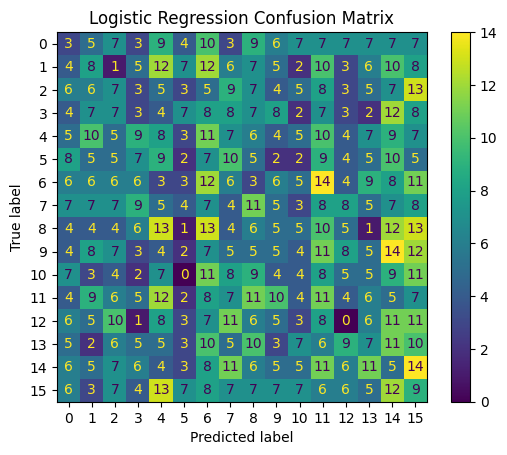


=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.06      0.05      0.05       101
           1       0.07      0.07      0.07       106
           2       0.08      0.07      0.07        96
           3       0.03      0.03      0.03        97
           4       0.08      0.10      0.09       110
           5       0.07      0.06      0.07        95
           6       0.03      0.04      0.03       108
           7       0.06      0.06      0.06       105
           8       0.07      0.09      0.08       106
           9       0.11      0.11      0.11       104
          10       0.11      0.11      0.11        97
          11       0.05      0.05      0.05       111
          12       0.02      0.02      0.02       101
          13       0.06      0.06      0.06       104
          14       0.08      0.07      0.08       113
          15       0.07      0.06      0.06       114

    accuracy                           0.07      1668
   

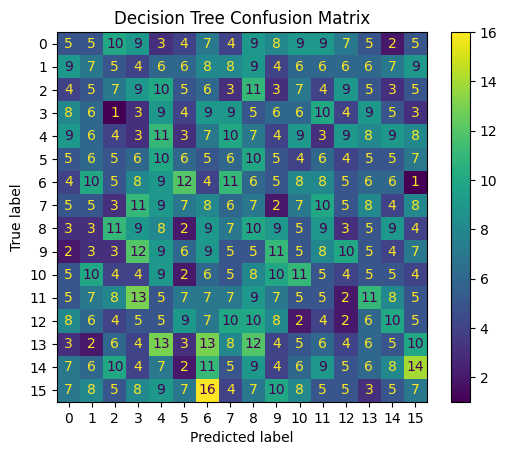


=== Naive Bayes ===
              precision    recall  f1-score   support

           0       0.04      0.04      0.04       101
           1       0.10      0.10      0.10       106
           2       0.06      0.06      0.06        96
           3       0.04      0.03      0.04        97
           4       0.07      0.08      0.08       110
           5       0.05      0.04      0.04        95
           6       0.09      0.11      0.10       108
           7       0.06      0.09      0.07       105
           8       0.08      0.08      0.08       106
           9       0.09      0.07      0.08       104
          10       0.04      0.03      0.03        97
          11       0.06      0.07      0.07       111
          12       0.01      0.01      0.01       101
          13       0.05      0.05      0.05       104
          14       0.04      0.04      0.04       113
          15       0.07      0.07      0.07       114

    accuracy                           0.06      1668
   ma

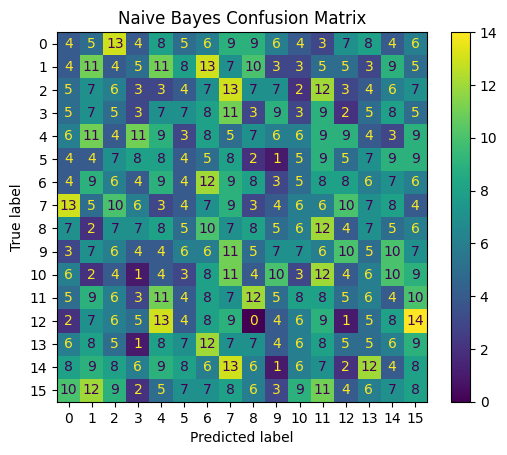


=== SVM ===
              precision    recall  f1-score   support

           0       0.03      0.03      0.03       101
           1       0.07      0.08      0.08       106
           2       0.06      0.05      0.06        96
           3       0.03      0.02      0.02        97
           4       0.04      0.04      0.04       110
           5       0.03      0.03      0.03        95
           6       0.10      0.13      0.11       108
           7       0.05      0.06      0.05       105
           8       0.06      0.06      0.06       106
           9       0.08      0.06      0.07       104
          10       0.07      0.06      0.06        97
          11       0.06      0.07      0.07       111
          12       0.08      0.07      0.07       101
          13       0.07      0.06      0.06       104
          14       0.03      0.04      0.03       113
          15       0.07      0.08      0.07       114

    accuracy                           0.06      1668
   macro avg 

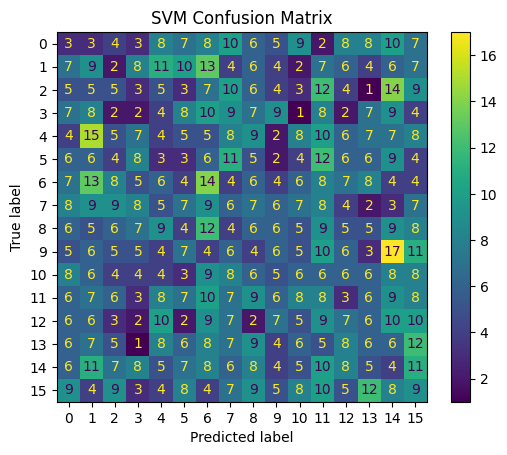


=== KNN ===
              precision    recall  f1-score   support

           0       0.07      0.24      0.11       101
           1       0.05      0.14      0.08       106
           2       0.06      0.11      0.08        96
           3       0.04      0.05      0.04        97
           4       0.08      0.08      0.08       110
           5       0.05      0.04      0.05        95
           6       0.07      0.06      0.06       108
           7       0.03      0.02      0.02       105
           8       0.05      0.02      0.03       106
           9       0.05      0.03      0.04       104
          10       0.03      0.01      0.02        97
          11       0.08      0.05      0.07       111
          12       0.07      0.03      0.04       101
          13       0.09      0.04      0.05       104
          14       0.06      0.04      0.04       113
          15       0.04      0.02      0.02       114

    accuracy                           0.06      1668
   macro avg 

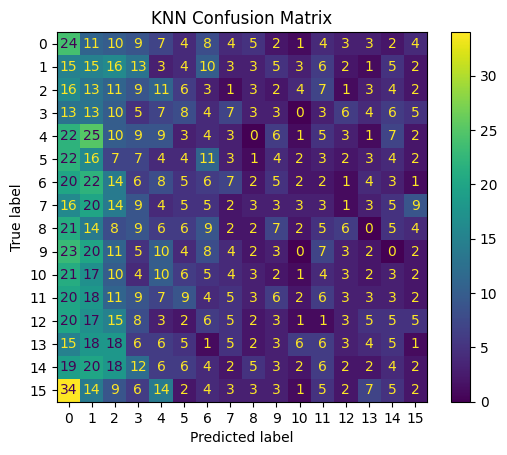


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.06      0.06      0.06       101
           1       0.07      0.06      0.06       106
           2       0.06      0.06      0.06        96
           3       0.05      0.03      0.04        97
           4       0.04      0.05      0.04       110
           5       0.08      0.08      0.08        95
           6       0.04      0.06      0.05       108
           7       0.06      0.07      0.06       105
           8       0.07      0.08      0.08       106
           9       0.06      0.05      0.05       104
          10       0.07      0.05      0.06        97
          11       0.10      0.12      0.11       111
          12       0.04      0.04      0.04       101
          13       0.10      0.10      0.10       104
          14       0.09      0.09      0.09       113
          15       0.08      0.08      0.08       114

    accuracy                           0.07      1668
   

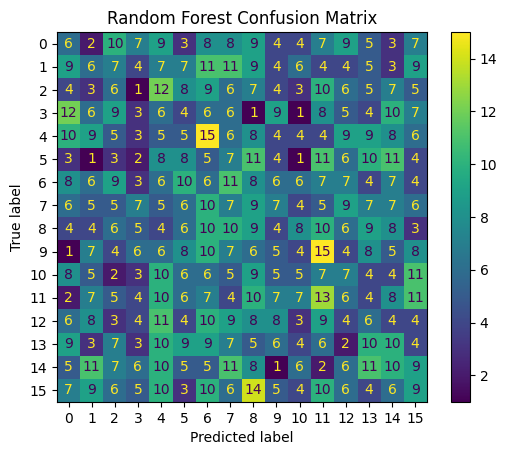


=== XGBoost ===


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:48:10] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

           0       0.03      0.03      0.03       101
           1       0.08      0.07      0.07       106
           2       0.05      0.04      0.04        96
           3       0.03      0.03      0.03        97
           4       0.09      0.09      0.09       110
           5       0.05      0.04      0.04        95
           6       0.06      0.06      0.06       108
           7       0.03      0.03      0.03       105
           8       0.06      0.07      0.06       106
           9       0.11      0.12      0.11       104
          10       0.13      0.11      0.12        97
          11       0.08      0.08      0.08       111
          12       0.09      0.09      0.09       101
          13       0.05      0.05      0.05       104
          14       0.07      0.08      0.07       113
          15       0.09      0.11      0.10       114

    accuracy                           0.07      1668
   macro avg       0.07   

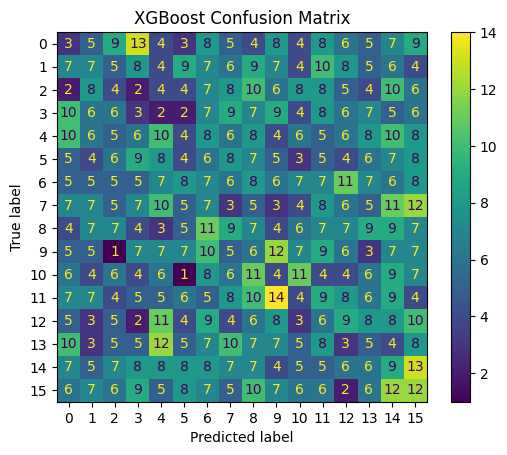

In [27]:



# X = some_feature_matrix (sparse or dense)
# y = target_labels (1D array)

# Split data into training and test sets
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# If X_tr is sparse, convert it to a dense matrix
if issparse(X_tr):
    X_tr = X_tr.toarray()  # Convert sparse matrix to dense
    X_te = X_te.toarray()  # Do the same for the test set

# Check if any negative values exist after conversion to dense format
if np.any(X_tr < 0):
    print("Negative values found in the training data.")
    # Replace negative values with 0
    X_tr = np.maximum(X_tr, 0)
    X_te = np.maximum(X_te, 0)

# Ensure that there are no negative values left
assert np.all(X_tr >= 0), "There are still negative values in the training data!"
assert np.all(X_te >= 0), "There are still negative values in the test data!"

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree"      : DecisionTreeClassifier(),
    "Naive Bayes"        : ComplementNB(),
    "SVM"                : LinearSVC(max_iter=5000),
    "KNN"                : KNeighborsClassifier(),
    "Random Forest"      : RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost"            : XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)  # Add XGBoost model
}

# Train the models and evaluate
for name, m in models.items():
    print(f"\n=== {name} ===")
    m.fit(X_tr, y_tr)  # Train the model
    preds = m.predict(X_te)  # Make predictions on the test set
    print(classification_report(y_te, preds))  # Print classification report
    ConfusionMatrixDisplay.from_predictions(y_te, preds)
    plt.title(f"{name} Confusion Matrix")
    plt.show()  # Display confusion matrix


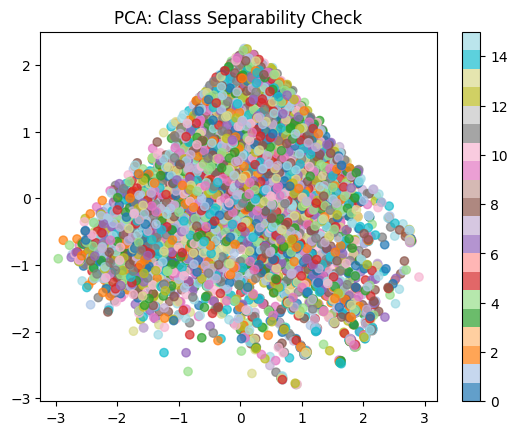

In [29]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab20', alpha=0.7)
plt.title("PCA: Class Separability Check")
plt.colorbar()
plt.show()
